# Module import

In [1]:
from netCDF4 import Dataset                             
import numpy as np            

import matplotlib.pyplot as plt           
import matplotlib.colors as mcolors              
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader

import sys
import torch 
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta

import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

In [2]:
sys.path.append("/home/users/mendrika/NCAST/NCAST/model/base")
from ncast import Core2MapModel

# Choose nowcast origin and lead time (in hour)

In [3]:
year = "2024"
month = "09"
day = "27"
hour = "12"
minute = "15"

In [4]:
lead_time = 1

# Configurations

In [5]:
DISPLAY_LON_MIN = -18.5
DISPLAY_LON_MAX = -4.45
DISPLAY_LAT_MIN = 5.1
DISPLAY_LAT_MAX = 19.5

# Ground truth 

In [6]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [7]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    
    nowcast_origin = {
        "year":   year,
        "month":  month,
        "day":    day,
        "hour":   hour,
        "minute": minute,
    }

    nowcast_lt = update_hour(nowcast_origin, hours_to_add=lead_time, minutes_to_add=0)["time"]

    path_core = f"/gws/ssde/j25b/cocoon/SSA_domain/ch9_wavelet/{nowcast_lt['year']}/{nowcast_lt['month']}"
    file = f"{path_core}/{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    return Dataset(file, mode='r')["cores"]

In [8]:
y_min, y_max = 1403, 1914
x_min, x_max = 66, 577

In [9]:
ground_truth = load_wavelet_dataset(year, month, day, hour, minute, lead_time)[0, y_min:y_max+1, x_min:x_max+1] != 0

In [10]:
geodata = np.load("/gws/ssde/j25b/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

In [11]:
def load_zcast_input(year, month, day, hour, minute, lead_time):
    input_path_ncast = f"/work/scratch-nopw2/mendrika/OB/ncast/raw/inputs_t0"
    core_input = f"{input_path_ncast}/input-{year}{month}{day}_{hour}{minute}.pt"
    return torch.load(core_input)

In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
ckpt = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/OB/ncast/checkpoints/t1/seed1998/best-ncast.ckpt"
model = Core2MapModel.load_from_checkpoint(ckpt, map_location=DEVICE)

In [14]:
SCALER_PATH = "/home/users/mendrika/Object-Based-LSTMConv/outputs/scaler/scaler_realcores.pt"

MASK_COL_INDEX = 12
COLS_TO_SCALE = range(4, 12)

# load scaler
scaler = torch.load(SCALER_PATH, weights_only=False)
mean = np.asarray(scaler["mean"])
scale = np.asarray(scaler["scale"])

In [15]:
try:
    # load one instance
    zcast_input = load_zcast_input(year, month, day, hour, minute, 0)

    X = zcast_input["input_tensor"].clone()

    X_np = X.numpy()

    flat = X_np.reshape(-1, X_np.shape[-1])

    flat[:, COLS_TO_SCALE] = (flat[:, COLS_TO_SCALE] - mean) / scale

    X_scaled = torch.tensor(
        flat.reshape(X_np.shape),
        dtype=torch.float32
    )

    input_scaled = X_scaled.unsqueeze(0).to(DEVICE)

    pred = torch.sigmoid(model(input_scaled)).squeeze(0).squeeze(0).detach().numpy()

except Exception as e:
    print(f"No data: {e}")

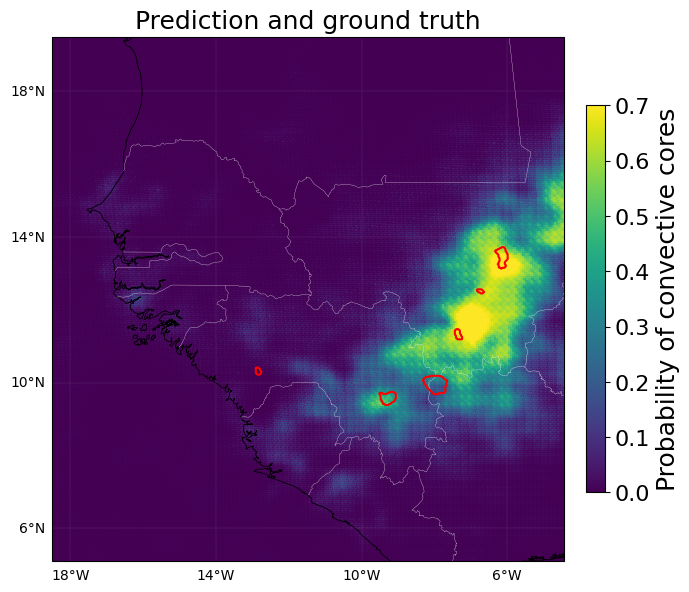

In [16]:
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX],
    crs=ccrs.PlateCarree()
)

ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="white", linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.2)

gl = ax.gridlines(
    draw_labels=True,
    alpha=1,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(-18, 6, 4),
    ylocs=np.arange(6, 21, 4),
)

gl.top_labels = False
gl.right_labels = False

masked_pred = np.ma.masked_where(pred <= 0, pred)

im = ax.pcolormesh(
    lons,
    lats,
    masked_pred.squeeze(),
    cmap="viridis",
    vmin=0,
    vmax=0.7,
    transform=ccrs.PlateCarree(),
    zorder=1,
)

gt_s = gaussian_filter(ground_truth.astype(float), sigma=0.4)

ax.contour(
    lons,
    lats,
    gt_s.squeeze(),
    levels=[0.5],
    colors="red",
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

ax.set_title("Prediction and ground truth", fontsize=18)
ax.set_xlabel("Longitude", fontsize=18)
ax.set_ylabel("Latitude", fontsize=18)

cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.035, pad=0.04)
cbar.set_label("Probability of convective cores", fontsize=18)
cbar.ax.tick_params(labelsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linewidth=0.1)

plt.tight_layout()
plt.show()

In [36]:
test = torch.load("/work/scratch-nopw2/mendrika/OB/ncast/evaluation/nowcasts/noattention/t6/202106/23/pred_20210606_2315.pt")['pred'].numpy()

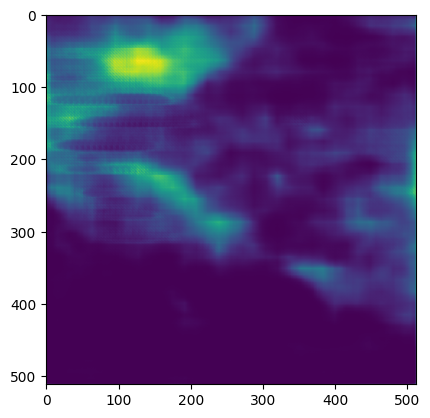

In [37]:
plt.imshow(test)